In [1]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob


import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget, RunSelectorUI, scan_runs
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [67]:
pgroup = 'p23084'
runlist = [254,255,256,260]
#runlist = np.arange(180, 186)

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 254


100%|██████████| 71/71 [00:31<00:00,  2.28it/s]


Processing run 255


100%|██████████| 71/71 [00:31<00:00,  2.28it/s]


Processing run 256


100%|██████████| 71/71 [00:31<00:00,  2.27it/s]


Processing run 260


100%|██████████| 67/67 [00:29<00:00,  2.30it/s]


In [3]:
#plot_merged_data(data, meta, Signal='diode1', Izero='Izero122', TT='124', withTT=True, bins=100, figsize=(10, 3))

In [68]:
ui, out  = Rebin_widget(data=data)
ui


In [69]:
data_plot1 = out["signal1"]
data_plot2 = out["signal2"]

Data saved in /sf/alvra/data/p23084/work/Reduced_data/_multiruns/run0254_0255_0256_0260/


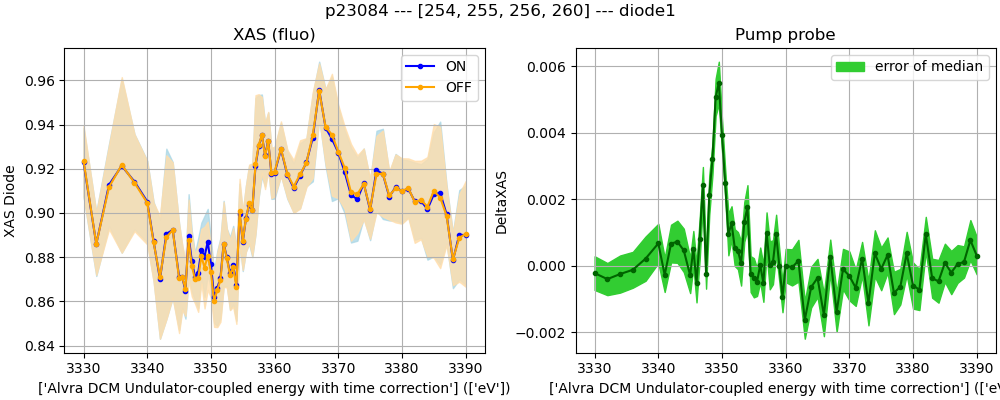

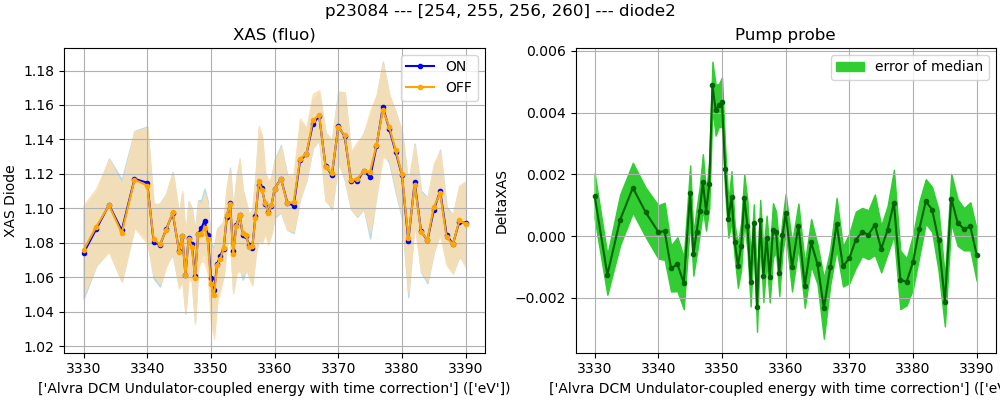

In [70]:
SaveDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2)

fig, axes = plotter.energy_scans(data_plot1, meta, errbars=False)
fig, axes = plotter.energy_scans(data_plot2, meta, errbars=False)

Data saved in /sf/alvra/data/p23084/work/Reduced_data/_multiruns/run0254_0255_0256_0260/


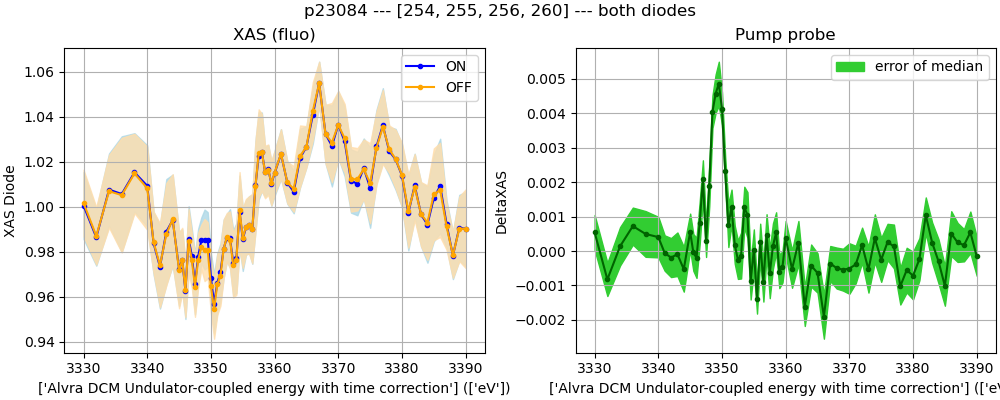

In [71]:
data_plot_both = average_two_diodes(data_plot1, data_plot2)
SaveData(SaveDir, runlist, plot1=data_plot1, plot2=data_plot2, plot_both=data_plot_both)
fig, axes = plotter.energy_scans(data_plot_both, meta, errbars=False)


In [53]:
4.7e-3/(np.pi*31.25**2)*1e8

153.1961820225348

In [31]:
8e-3/(np.pi*25**2)*1e8

407.4366543152521

In [ ]:
30000   40000   50000   60000   70000   80000   90000  100000
  200000  300000  400000  500000  600000  700000  800000  900000 1000000

# Overlay data with UI

In [27]:
pgroup = 'p23084'
which_plot = 'plot1'

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p23084/work/Reduced_data/_singlerun/run0256/data.npz
Loaded __diode1__ from: /sf/alvra/data/p23084/work/Reduced_data/_singlerun/run0255/data.npz
Loaded __diode1__ from: /sf/alvra/data/p23084/work/Reduced_data/_singlerun/run0254/data.npz


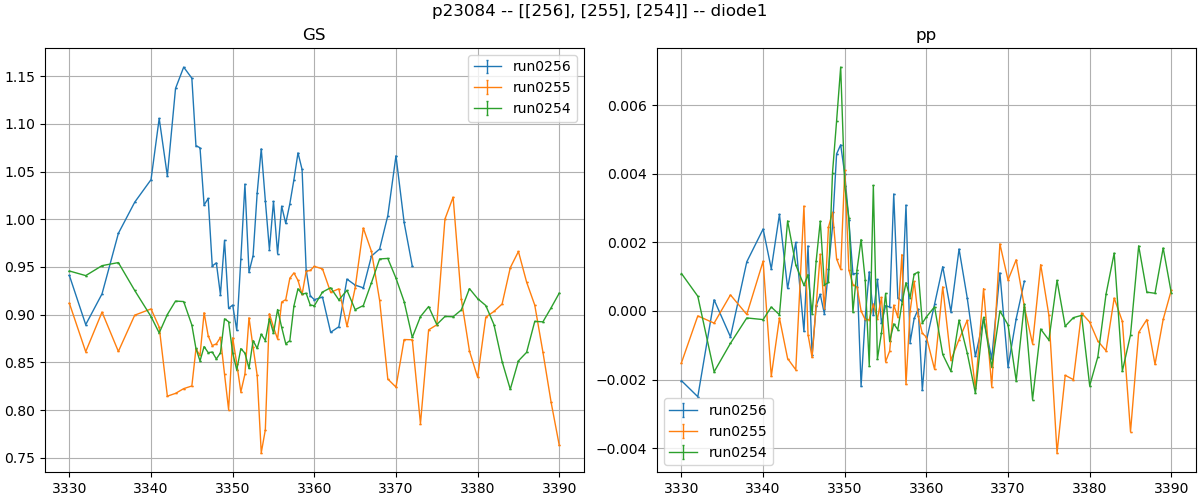

In [28]:
runlist2load = selector.runlist
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS, 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'lower left')
ax3.set_title('pp')
ax3.grid()
plt.show()

# Overlay data "manually"

In [64]:
pgroup = 'p23084'
runlist2load = [[22],[184]]

which_plot = 'plot1' #plot_both #plot1

LoadDir = '/sf/alvra/data/{}/work/Reduced_data/'.format(pgroup)
dataLoaded, runnames, whichdiode = LoadDataAuto(LoadDir, runlist2load, which_plot=which_plot)
#selector = RunSelectorUI(LoadDir)

Loaded __diode1__ from: /sf/alvra/data/p23084/work/Reduced_data/_singlerun/run0022/data.npz
Loaded __diode1__ from: /sf/alvra/data/p23084/work/Reduced_data/_singlerun/run0184/data.npz


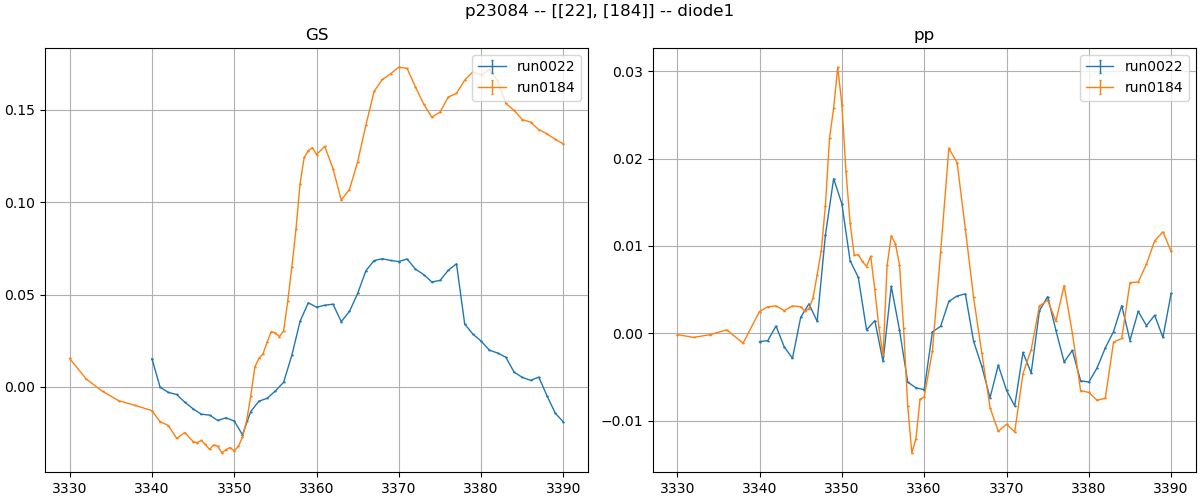

In [65]:
fig, ((ax1, ax3)) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for index, dataset in enumerate(dataLoaded):
    label = runnames[index]
    plt.suptitle('{} -- {} -- {}'.format(pgroup, runlist2load, whichdiode))
    d = dataset['results']
    GS = d['GS']
    err_GS = d['err_GS']
    ES = d['ES']
    err_ES = d['err_ES']
    pp = d['pp']
    err_pp = d['err_pp']
    rbk = d['scanvar_rebin']

    ax1.errorbar(rbk, GS - np.mean(GS[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    #ax1.errorbar(rbk, ES- np.mean(ES[:5]), 0, lw=1,markersize=0,capsize=1,capthick=1, elinewidth=1, label=label)
    ax3.errorbar(rbk, pp, 0, lw=1,markersize=0,capsize=1,capthick=1,elinewidth=1, label=label)
ax1.legend(loc = 'upper right')
ax1.grid()
ax1.set_title('GS')
ax3.legend(loc = 'upper right')
ax3.set_title('pp')
ax3.grid()
plt.show()
